# Definitive ProtoHedge Empirical Rerun

This is the single protocol-locked notebook for the final empirical paper. It runs the complete real-data experiment for:

- all processed tickers in `Data/NEW_PANEL_DECISION_V2/panel_manifest.csv`,
- European ATM short calls,
- arithmetic-average Asian ATM short calls,
- unhedged, Spot-Delta, Spot-Delta Band, Deep Hedging, and the full ProtoHedge grid,
- three seeds and 800 epochs,
- validation-only checkpoint and configuration selection, and
- paired seed-averaged circular-block confidence intervals.

It intentionally excludes the synthetic Black--Scholes and stochastic-volatility reproduction suites. Those are background reproductions, not part of the definitive empirical rerun.

The notebook writes to a fresh `submission_rerun_scientific_v4` directory, so superseded outputs cannot be reused accidentally. Completed ticker/liability sweeps are skipped safely when the notebook is restarted. A partially completed ticker is rerun from its beginning.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json
import os
import sys
import traceback

cwd = Path.cwd().resolve()
root_candidates = [cwd, *cwd.parents, Path.home() / 'deephedging']
REPO_ROOT = next(
    (candidate for candidate in root_candidates if (candidate / 'world_real_torch.py').exists()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError(
        f'Could not locate the repository root from {cwd}. '
        'Set the working directory to the repository or its notebooks folder.'
    )
REPO_ROOT = REPO_ROOT.resolve()

REPO_PARENT = REPO_ROOT.parent
if str(REPO_PARENT) not in sys.path:
    sys.path.insert(0, str(REPO_PARENT))

os.environ.setdefault('MPLCONFIGDIR', str(REPO_ROOT / '.matplotlib-cache'))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display, Markdown

from deephedging.hedge_accounting import HEDGE_ACCOUNTING_VERSION
from deephedging.outcome_metrics import (
    INFERENCE_VERSION,
    OUTCOME_DEFINITION_VERSION,
    PREMIUM_INCLUDED,
    paired_panel_seed_circular_block_bootstrap,
)
from deephedging.panel_data_pipeline import (
    EPISODE_TIMING_VERSION,
    OPTION_PATH_VERSION,
    TEMPORAL_SPLIT_VERSION,
)
from deephedging.payoff_state import (
    ASIAN_PAYOFF_FEATURE,
    ASIAN_PAYOFF_STATE_VERSION,
    model_features_for_liability,
    payoff_state_version_for_liability,
)
from deephedging.proto_analysis_torch import load_prototype_payload
from deephedging.prototype_extraction_torch import extract_agent_feature_matrix
from deephedging.real_data_analysis_torch import (
    build_regime_frame,
    evaluate_saved_artifact,
    evaluate_saved_baselines,
    list_saved_artifacts,
    prototype_usage_by_regime,
    prototype_usage_table,
    summarize_by_regime,
)
from deephedging.real_data_sweep_torch import (
    DEFAULT_SPOT_DELTA_BAND_GRID,
    MODEL_SELECTION_VERSION,
    VALIDATION_SELECTIONS,
    run_real_data_sweep,
)

pd.set_option('display.max_columns', 300)
pd.set_option('display.width', 220)
plt.rcParams['figure.dpi'] = 120

print('repository:', REPO_ROOT)
print('torch:', torch.__version__)
print('device:', 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))
print('outcome definition:', OUTCOME_DEFINITION_VERSION)
print('hedge accounting:', HEDGE_ACCOUNTING_VERSION)


repository: /Users/yaniszaim/deephedging
torch: 2.5.1
device: mps
outcome definition: liability-offset-excluding-premium-v1
hedge accounting: inventory-step-v1


## 1. Locked Run Configuration

The default settings below are the full paper run. Do not reduce epochs, seeds, prototype counts, or tickers for the submission results.

`SKIP_COMPLETED=True` makes restart safe at the ticker/liability level. Set `FORCE_RERUN` only if a completed corrected ticker must deliberately be replaced.


In [2]:
RUN_TRAINING = os.environ.get('PROTOHEDGE_RUN_TRAINING', '1') == '1'
RUN_ANALYSIS = os.environ.get('PROTOHEDGE_RUN_ANALYSIS', '1') == '1'

RUN_VERSION = os.environ.get('PROTOHEDGE_RUN_VERSION', 'submission_rerun_scientific_v4')
RUN_ROOT = REPO_ROOT / '.deephedging_real_runs' / RUN_VERSION
ASSET_ROOT = REPO_ROOT / 'paper' / RUN_VERSION
RUN_ROOT.mkdir(parents=True, exist_ok=True)
ASSET_ROOT.mkdir(parents=True, exist_ok=True)

PANEL_DIR = REPO_ROOT / 'Data' / 'NEW_PANEL_DECISION_V2'
MANIFEST_PATH = PANEL_DIR / 'panel_manifest.csv'

LIABILITY_CONFIGS = {
    'european_call': {
        'label': 'European',
        'asian_average_type': 'arithmetic',
        'asian_start_step': 1,
        'asian_end_step': None,
    },
    'asian_call': {
        'label': 'Asian',
        'asian_average_type': 'arithmetic',
        'asian_start_step': 1,
        'asian_end_step': None,
    },
}

EXPECTED_TICKERS = ('AAPL', 'IWM', 'NVDA', 'QQQ', 'SPY', 'TLT', 'XLE', 'XLF', 'XLK', 'XLV')
SEEDS = (1234, 2345, 3456)
EPOCHS = 800
LEARNING_RATE = 1e-3
BATCH_SIZE = None
EPOCH_REFRESH = None
SPOT_DELTA_BAND_GRID = tuple(DEFAULT_SPOT_DELTA_BAND_GRID)
PROTOTYPE_COUNTS = (10, 25, 50, 100)
PROTOTYPE_SOURCES = ('spot_delta', 'vanilla')
WEIGHTED_SIMILARITY_OPTIONS = (False, True)
LEARN_DISTANCE_FEATURE_WEIGHTS_OPTIONS = (False,)
RISK_MEASURES = ('cvar',)

TRADE_BOUNDS = {'lbnd_as': -1.0, 'ubnd_as': 1.0, 'lbnd_av': -1.0, 'ubnd_av': 1.0}
POSITION_BOUNDS = {'lbnd_delta_s': -1.0, 'ubnd_delta_s': 1.0, 'lbnd_delta_v': -1.0, 'ubnd_delta_v': 1.0}
TRAIN_SELECTION = {
    'selection_metric': 'val_loss',
    'selection_alpha_action_abs': 0.005,
    'selection_alpha_delta_abs': 0.010,
    'selection_alpha_bound_occupancy': 0.100,
    'selection_alpha_path_bound_touch': 0.0,
}
TRAIN_REGULARIZATION = {'action_penalty_weight': 0.001, 'delta_penalty_weight': 0.002}
MAX_VALIDATION_BOUND_OCCUPANCY = 0.50
BOOTSTRAP_REPETITIONS = 2000
BOOTSTRAP_CONFIDENCE = 0.95
BOOTSTRAP_BLOCK_LENGTH = 20

SKIP_COMPLETED = True
FORCE_RERUN = set()  # Example: {('asian_call', 'AAPL')}
DEEP_DIVE_TICKER = 'QQQ'
DEEP_DIVE_SEED = SEEDS[0]
DEEP_DIVE_SELECTION = 'best_screened_proto_cvar05'

PAPER_LABELS = {
    'unhedged': 'Unhedged',
    'spot_delta': 'Spot-Delta',
    'spot_delta_band': 'Spot-Delta Band',
    'vanilla': 'Deep Hedging',
}
PROTO_LABELS = {
    'best_screened_proto_mean': 'ProtoHedge (Validation-Mean)',
    'best_screened_proto_cvar05': 'ProtoHedge (Validation-Tail)',
}
PAPER_ORDER = [*PAPER_LABELS.values(), *PROTO_LABELS.values()]

COMPLETION_FILES = (
    'fixed_chronological_splits.npz',
    'fixed_episode_metadata.csv',
    'sweep_metrics.csv',
    'sweep_test_summary.csv',
    'paper_model_comparison.csv',
    'paper_best_models.csv',
    'validation_model_selection.csv',
    'validation_selected_models.csv',
    'paired_block_bootstrap.csv',
    'paired_test_liability_offsets.npz',
    'paired_test_liability_offsets_metadata.csv',
    'paper_selected_table.csv',
    'interpretation.md',
    'sweep_test_liability_offset_mean.png',
    'sweep_test_liability_offset_cvar05.png',
    'sweep_test_liability_offset_rmse.png',
    'sweep_test_liability_offset_downside_deviation.png',
    'sweep_test_bound_saturation.png',
    'proto_validation_offset_vs_n_prototypes.png',
    'proto_validation_offset_cvar05_vs_n_prototypes.png',
    'sweep_config.json',
)

n_proto_configs = len(PROTOTYPE_COUNTS) * len(PROTOTYPE_SOURCES) * len(WEIGHTED_SIMILARITY_OPTIONS)
learned_fits_per_ticker_liability = len(SEEDS) * (1 + n_proto_configs)
print('RUN_TRAINING:', RUN_TRAINING)
print('RUN_ANALYSIS:', RUN_ANALYSIS)
print('run root:', RUN_ROOT)
print('asset root:', ASSET_ROOT)
print('ProtoHedge configurations:', n_proto_configs)
print('learned fits per ticker/liability:', learned_fits_per_ticker_liability)


RUN_TRAINING: True
RUN_ANALYSIS: True
run root: /Users/yaniszaim/deephedging/.deephedging_real_runs/submission_rerun_scientific_v4
asset root: /Users/yaniszaim/deephedging/paper/submission_rerun_scientific_v4
ProtoHedge configurations: 16
learned fits per ticker/liability: 51


## 2. Scientific Preflight Gate

This cell refuses to start a multi-day run unless the panel uses chronological pre-window splits and fixed option contracts. It also verifies that the Asian policy contains running-average moneyness.

The repository test suite includes timing, accounting, split, contract, Asian-state, outcome, and selection checks across hedge accounting, temporal splits, contract continuity, Asian state, outcome metrics, and validation-only selection.


In [3]:
assert MANIFEST_PATH.exists(), f'Missing manifest: {MANIFEST_PATH}'
raw_manifest = pd.read_csv(MANIFEST_PATH).sort_values('ticker').reset_index(drop=True)
assert set(raw_manifest['ticker']) == set(EXPECTED_TICKERS), (
    f'Expected exactly {EXPECTED_TICKERS}, found {sorted(raw_manifest["ticker"].tolist())}'
)
failed_manifest = raw_manifest[~raw_manifest['status'].eq('ok')]
assert failed_manifest.empty, 'Every intended ticker must have status=ok:\n' + failed_manifest.to_string(index=False)
manifest = raw_manifest.copy()

required_columns = {
    'ticker', 'episode_path', 'split_path', 'episode_metadata_path',
    'split_version', 'option_path_version', 'episode_timing_version',
    'n_steps', 'n_observations',
    'n_train_episodes', 'n_val_episodes', 'n_test_episodes',
}
missing_columns = required_columns.difference(manifest.columns)
assert not missing_columns, f'Manifest is missing columns: {sorted(missing_columns)}'
assert manifest['split_version'].eq(TEMPORAL_SPLIT_VERSION).all()
assert manifest['option_path_version'].eq(OPTION_PATH_VERSION).all()
assert manifest['episode_timing_version'].eq(EPISODE_TIMING_VERSION).all()
assert manifest['n_steps'].eq(20).all()
assert manifest['n_observations'].eq(21).all()

for _, row in manifest.iterrows():
    for col in ('episode_path', 'split_path', 'episode_metadata_path'):
        assert Path(row[col]).exists(), f"{row['ticker']} missing {col}: {row[col]}"
    shape = np.load(row['episode_path'], mmap_mode='r').shape
    assert shape[1:] == (21, 5), f"{row['ticker']} invalid episode shape: {shape}"

assert payoff_state_version_for_liability('european_call') is None
assert payoff_state_version_for_liability('asian_call') == ASIAN_PAYOFF_STATE_VERSION
assert ASIAN_PAYOFF_FEATURE in model_features_for_liability('asian_call')
assert PREMIUM_INCLUDED is False

n_tickers = len(manifest)
planned_fits = n_tickers * len(LIABILITY_CONFIGS) * learned_fits_per_ticker_liability
print('tickers:', manifest['ticker'].tolist())
print('episodes:', int(manifest['n_episodes'].sum()))
print('train/validation/test:', int(manifest['n_train_episodes'].sum()), int(manifest['n_val_episodes'].sum()), int(manifest['n_test_episodes'].sum()))
print('planned learned fits:', planned_fits)
display(manifest[['ticker', 'n_episodes', 'n_train_episodes', 'n_val_episodes', 'n_test_episodes', 'test_episode_start_date', 'test_episode_end_date']])


tickers: ['AAPL', 'IWM', 'NVDA', 'QQQ', 'SPY', 'TLT', 'XLE', 'XLF', 'XLK', 'XLV']
episodes: 34395
train/validation/test: 20537 6881 6977
planned learned fits: 1020


,ticker,n_episodes,n_train_episodes,n_val_episodes,n_test_episodes,test_episode_start_date,test_episode_end_date
0,AAPL,3478,2081,686,711,2022-02-01,2024-12-31
1,IWM,3761,2352,696,713,2022-02-01,2024-12-31
2,NVDA,3085,1775,666,644,2022-02-01,2024-12-31
3,QQQ,3755,2350,713,692,2022-02-01,2024-12-31
4,SPY,3819,2390,716,713,2022-02-01,2024-12-31
5,TLT,3444,2026,706,712,2022-02-01,2024-12-31
6,XLE,3564,2214,640,710,2022-02-01,2024-12-30
7,XLF,3326,1939,682,705,2022-02-01,2024-12-31
8,XLK,3037,1643,697,697,2022-02-01,2024-12-31
9,XLV,3126,1767,679,680,2022-02-01,2024-12-26


## 3. Completion and Training Helpers

A sweep counts as complete only if all expected files exist and its saved configuration matches the locked protocol. A directory from any earlier protocol cannot satisfy this gate.


In [4]:
def ticker_output_dir(liability_type, ticker):
    return RUN_ROOT / liability_type / f'{ticker}_full_grid_{EPOCHS}_epochs'


def expected_features(liability_type):
    return sorted(model_features_for_liability(liability_type))


def ticker_is_complete(liability_type, ticker):
    out_dir = ticker_output_dir(liability_type, ticker)
    if not all((out_dir / name).exists() for name in COMPLETION_FILES):
        return False
    try:
        cfg = json.loads((out_dir / 'sweep_config.json').read_text())
    except (OSError, json.JSONDecodeError):
        return False
    temporal = cfg.get('temporal_split', {})
    protocol_ok = all([
        cfg.get('checkpoint_stage') == 'complete',
        cfg.get('outcome_definition') == OUTCOME_DEFINITION_VERSION,
        cfg.get('premium_included') is False,
        cfg.get('model_selection_version') == MODEL_SELECTION_VERSION,
        cfg.get('hedge_accounting_version') == HEDGE_ACCOUNTING_VERSION,
        cfg.get('inference_version') == INFERENCE_VERSION,
        cfg.get('episode_timing_version') == EPISODE_TIMING_VERSION,
        cfg.get('liability_type') == liability_type,
        temporal.get('split_version') == TEMPORAL_SPLIT_VERSION,
        temporal.get('option_path_version') == OPTION_PATH_VERSION,
        temporal.get('episode_timing_version') == EPISODE_TIMING_VERSION,
        int(temporal.get('n_steps', -1)) == 20,
        int(temporal.get('n_observations', -1)) == 21,
        sorted(cfg.get('model_features', [])) == expected_features(liability_type),
        tuple(cfg.get('seeds', [])) == SEEDS,
        int(cfg.get('epochs', -1)) == EPOCHS,
        float(cfg.get('lr', -1.0)) == LEARNING_RATE,
        cfg.get('batch_size') == BATCH_SIZE,
        cfg.get('epoch_refresh') == EPOCH_REFRESH,
        cfg.get('normalize') is True,
        cfg.get('hedge_mode') == 'step',
        cfg.get('position_bounds') is True,
        cfg.get('selection_metric') == TRAIN_SELECTION['selection_metric'],
        float(cfg.get('selection_alpha_action_abs', -1.0)) == TRAIN_SELECTION['selection_alpha_action_abs'],
        float(cfg.get('selection_alpha_delta_abs', -1.0)) == TRAIN_SELECTION['selection_alpha_delta_abs'],
        float(cfg.get('selection_alpha_bound_occupancy', -1.0)) == TRAIN_SELECTION['selection_alpha_bound_occupancy'],
        float(cfg.get('selection_alpha_path_bound_touch', -1.0)) == TRAIN_SELECTION['selection_alpha_path_bound_touch'],
        float(cfg.get('action_penalty_weight', -1.0)) == TRAIN_REGULARIZATION['action_penalty_weight'],
        float(cfg.get('delta_penalty_weight', -1.0)) == TRAIN_REGULARIZATION['delta_penalty_weight'],
        float(cfg.get('max_bound_occupancy', -1.0)) == MAX_VALIDATION_BOUND_OCCUPANCY,
        cfg.get('max_path_touch_rate') is None,
        tuple(cfg.get('spot_delta_band_grid', [])) == SPOT_DELTA_BAND_GRID,
        cfg.get('tuned_baseline_metric') == 'liability_offset_mean',
        cfg.get('validation_selection_objectives') == VALIDATION_SELECTIONS,
        cfg.get('payoff_state_version') == payoff_state_version_for_liability(liability_type),
        cfg.get('asian_average_type') == 'arithmetic',
        int(cfg.get('asian_start_step', -1)) == 1,
        cfg.get('asian_end_step') is None,
        tuple(cfg.get('prototype_counts', [])) == PROTOTYPE_COUNTS,
        tuple(cfg.get('prototype_sources', [])) == PROTOTYPE_SOURCES,
        tuple(cfg.get('weighted_similarity_options', [])) == WEIGHTED_SIMILARITY_OPTIONS,
        tuple(cfg.get('learn_distance_feature_weights_options', [])) == LEARN_DISTANCE_FEATURE_WEIGHTS_OPTIONS,
        tuple(cfg.get('risk_measures', [])) == RISK_MEASURES,
        int(cfg.get('bootstrap_repetitions', -1)) == BOOTSTRAP_REPETITIONS,
        float(cfg.get('bootstrap_confidence', -1.0)) == BOOTSTRAP_CONFIDENCE,
        int(cfg.get('bootstrap_block_length', -1)) == BOOTSTRAP_BLOCK_LENGTH,
        cfg.get('trade_bounds') == TRADE_BOUNDS,
        cfg.get('cumulative_bounds') == POSITION_BOUNDS,
    ])
    if not protocol_ok:
        return False
    if any((out_dir / name).stat().st_size == 0 for name in COMPLETION_FILES):
        return False
    artifacts = list_saved_artifacts(out_dir)
    if len(artifacts) != learned_fits_per_ticker_liability:
        return False
    if set(artifacts['seed'].astype(int)) != set(SEEDS):
        return False
    expected_artifacts_per_seed = 1 + n_proto_configs
    if not artifacts.groupby('seed').size().eq(expected_artifacts_per_seed).all():
        return False
    if artifacts.duplicated(['seed', 'risk_measure', 'model_name']).any():
        return False
    best = pd.read_csv(out_dir / 'paper_best_models.csv')
    if set(best['selection']) != set(PROTO_LABELS) or len(best) != len(PROTO_LABELS):
        return False
    if not best['selection_split'].eq('validation').all():
        return False
    validation_grid = pd.read_csv(out_dir / 'validation_model_selection.csv')
    if len(validation_grid) != n_proto_configs:
        return False
    if not validation_grid['n_seed_runs'].eq(len(SEEDS)).all():
        return False
    frozen = pd.read_csv(out_dir / 'validation_selected_models.csv')
    if len(frozen) != len(PROTO_LABELS) or set(frozen['selection']) != set(PROTO_LABELS):
        return False
    if not frozen['selection_split'].eq('validation').all():
        return False
    metrics = pd.read_csv(out_dir / 'sweep_metrics.csv')
    for model in PAPER_LABELS:
        rows = metrics[(metrics['model'].eq(model)) & metrics['split'].eq('test')]
        if len(rows) != len(SEEDS) or set(rows['seed'].astype(int)) != set(SEEDS):
            return False
    for model in best['model'].astype(str).unique():
        rows = metrics[(metrics['model'].eq(model)) & metrics['split'].eq('test')]
        if len(rows) != len(SEEDS) or set(rows['seed'].astype(int)) != set(SEEDS):
            return False
    bootstrap = pd.read_csv(out_dir / 'paired_block_bootstrap.csv')
    if set(bootstrap['selection']) != set(PROTO_LABELS):
        return False
    if not bootstrap['selection_split'].eq('validation').all():
        return False
    paired_meta = pd.read_csv(out_dir / 'paired_test_liability_offsets_metadata.csv')
    if len(paired_meta) != len(PROTO_LABELS) or set(paired_meta['selection']) != set(PROTO_LABELS):
        return False
    if not paired_meta['n_seeds'].eq(len(SEEDS)).all():
        return False
    return True


def run_one_ticker(liability_type, liability_cfg, row):
    ticker = str(row['ticker'])
    out_dir = ticker_output_dir(liability_type, ticker)
    out_dir.mkdir(parents=True, exist_ok=True)
    if SKIP_COMPLETED and (liability_type, ticker) not in FORCE_RERUN and ticker_is_complete(liability_type, ticker):
        print(f'[{liability_type}] {ticker}: complete corrected sweep found; skipping')
        return pd.read_csv(out_dir / 'sweep_metrics.csv')

    print(f'[{liability_type}] {ticker}: starting full sweep at {datetime.now().isoformat(timespec="seconds")}')
    return run_real_data_sweep(
        data_path=row['episode_path'],
        split_path=row['split_path'],
        episode_metadata_path=row['episode_metadata_path'],
        output_dir=out_dir,
        samples=None,
        seeds=SEEDS,
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        batch_size=BATCH_SIZE,
        epoch_refresh=EPOCH_REFRESH,
        spot_delta_band_grid=SPOT_DELTA_BAND_GRID,
        prototype_counts=PROTOTYPE_COUNTS,
        prototype_sources=PROTOTYPE_SOURCES,
        weighted_similarity_options=WEIGHTED_SIMILARITY_OPTIONS,
        learn_distance_feature_weights_options=LEARN_DISTANCE_FEATURE_WEIGHTS_OPTIONS,
        risk_measures=RISK_MEASURES,
        normalize=True,
        hedge_mode='step',
        position_bounds=True,
        trade_bounds=TRADE_BOUNDS,
        cumulative_bounds=POSITION_BOUNDS,
        liability_type=liability_type,
        asian_average_type=liability_cfg['asian_average_type'],
        asian_start_step=liability_cfg['asian_start_step'],
        asian_end_step=liability_cfg['asian_end_step'],
        selection_metric=TRAIN_SELECTION['selection_metric'],
        selection_alpha_action_abs=TRAIN_SELECTION['selection_alpha_action_abs'],
        selection_alpha_delta_abs=TRAIN_SELECTION['selection_alpha_delta_abs'],
        selection_alpha_bound_occupancy=TRAIN_SELECTION['selection_alpha_bound_occupancy'],
        selection_alpha_path_bound_touch=TRAIN_SELECTION['selection_alpha_path_bound_touch'],
        action_penalty_weight=TRAIN_REGULARIZATION['action_penalty_weight'],
        delta_penalty_weight=TRAIN_REGULARIZATION['delta_penalty_weight'],
        max_bound_occupancy=MAX_VALIDATION_BOUND_OCCUPANCY,
        max_path_touch_rate=None,
        tuned_baseline_metric='liability_offset_mean',
        bootstrap_repetitions=BOOTSTRAP_REPETITIONS,
        bootstrap_confidence=BOOTSTRAP_CONFIDENCE,
        bootstrap_block_length=BOOTSTRAP_BLOCK_LENGTH,
    )


def write_run_status(rows):
    path = RUN_ROOT / 'run_status.csv'
    pd.DataFrame(rows).to_csv(path, index=False)
    return path


## 4. Full European and Asian Training

**This is the expensive cell.** It runs European first and Asian second. Status is written after every ticker. If the kernel or machine stops, rerun the notebook: completed ticker/liability pairs will be skipped after their protocol metadata is verified.


In [5]:
run_status = []
if RUN_TRAINING:
    for liability_type, liability_cfg in LIABILITY_CONFIGS.items():
        for _, row in manifest.iterrows():
            ticker = str(row['ticker'])
            started = datetime.now(timezone.utc)
            status_row = {
                'liability_type': liability_type,
                'ticker': ticker,
                'started_utc': started.isoformat(),
                'output_dir': str(ticker_output_dir(liability_type, ticker)),
            }
            try:
                run_one_ticker(liability_type, liability_cfg, row)
                status_row['status'] = 'complete'
                status_row['error'] = ''
            except Exception as exc:
                status_row['status'] = 'failed'
                status_row['error'] = repr(exc)
                status_row['finished_utc'] = datetime.now(timezone.utc).isoformat()
                run_status.append(status_row)
                write_run_status(run_status)
                traceback.print_exc()
                raise
            status_row['finished_utc'] = datetime.now(timezone.utc).isoformat()
            status_row['elapsed_hours'] = (datetime.now(timezone.utc) - started).total_seconds() / 3600.0
            run_status.append(status_row)
            write_run_status(run_status)
            print(f"[{liability_type}] {ticker}: COMPLETE in {status_row['elapsed_hours']:.2f} hours")
else:
    print('RUN_TRAINING=False: training skipped')


[european_call] AAPL: complete corrected sweep found; skipping
[european_call] AAPL: COMPLETE in 0.00 hours
[european_call] IWM: complete corrected sweep found; skipping
[european_call] IWM: COMPLETE in 0.00 hours
[european_call] NVDA: complete corrected sweep found; skipping
[european_call] NVDA: COMPLETE in 0.00 hours
[european_call] QQQ: complete corrected sweep found; skipping
[european_call] QQQ: COMPLETE in 0.00 hours
[european_call] SPY: complete corrected sweep found; skipping
[european_call] SPY: COMPLETE in 0.00 hours
[european_call] TLT: complete corrected sweep found; skipping
[european_call] TLT: COMPLETE in 0.00 hours
[european_call] XLE: starting full sweep at 2026-08-09T21:42:08
Resume checkpoint found | rows=116 | stage=seed_3456_risk_cvar_source_vanilla_k_50_weighted_1_learnw_0
fixed chronological split | train=2214 | val=640 | test=710 | version=chronological-prewindow-v1 | option_path=fixed-optionid-v1 | payoff_state=terminal-only | features=['delta', 'price', 'time

## 5. Hard Completion Audit

Analysis is allowed only when every ticker and both liabilities pass the completion gate. This prevents a partially completed run from silently producing a paper table.


In [6]:
completion_rows = []
for liability_type in LIABILITY_CONFIGS:
    for ticker in manifest['ticker']:
        completion_rows.append({
            'liability_type': liability_type,
            'ticker': ticker,
            'complete': ticker_is_complete(liability_type, ticker),
            'output_dir': str(ticker_output_dir(liability_type, ticker)),
        })
completion_df = pd.DataFrame(completion_rows)
completion_df.to_csv(RUN_ROOT / 'completion_audit.csv', index=False)
display(completion_df)

if RUN_ANALYSIS:
    incomplete = completion_df[~completion_df['complete']]
    assert incomplete.empty, 'Analysis blocked because these sweeps are incomplete:\n' + incomplete.to_string(index=False)
    print('COMPLETION GATE PASSED: all ticker/liability sweeps are complete.')
else:
    print('RUN_ANALYSIS=False: completion shown for dry validation only.')


,liability_type,ticker,complete,output_dir
0,european_call,AAPL,True,/Users/yaniszaim/deephedging/.deephedging_real...
1,european_call,IWM,True,/Users/yaniszaim/deephedging/.deephedging_real...
2,european_call,NVDA,True,/Users/yaniszaim/deephedging/.deephedging_real...
3,european_call,QQQ,True,/Users/yaniszaim/deephedging/.deephedging_real...
4,european_call,SPY,True,/Users/yaniszaim/deephedging/.deephedging_real...
5,european_call,TLT,True,/Users/yaniszaim/deephedging/.deephedging_real...
6,european_call,XLE,True,/Users/yaniszaim/deephedging/.deephedging_real...
7,european_call,XLF,True,/Users/yaniszaim/deephedging/.deephedging_real...
8,european_call,XLK,True,/Users/yaniszaim/deephedging/.deephedging_real...
9,european_call,XLV,True,/Users/yaniszaim/deephedging/.deephedging_real...


COMPLETION GATE PASSED: all ticker/liability sweeps are complete.


## 6. Aggregate Paper Tables and Panel Inference

The tables use baselines plus only the two ProtoHedge configurations frozen by validation. Candidate configurations that were not selected never enter the test comparison.


In [7]:
def select_row(best_df, selection):
    rows = best_df[best_df['selection'].eq(selection)]
    if len(rows) != 1:
        raise RuntimeError(f'Expected exactly one {selection} row, found {len(rows)}')
    row = rows.iloc[0]
    assert row['selection_split'] == 'validation'
    assert row['model_selection_version'] == MODEL_SELECTION_VERSION
    return row


def save_table(df, path, index=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path.with_suffix('.csv'), index=index)
    path.with_suffix('.tex').write_text(df.to_latex(index=index, escape=True, float_format=lambda x: f'{x:.6f}'))
    return path.with_suffix('.csv')


def aggregate_liability(liability_type):
    label = LIABILITY_CONFIGS[liability_type]['label']
    table_dir = ASSET_ROOT / liability_type / 'tables'
    table_dir.mkdir(parents=True, exist_ok=True)
    rows = []
    selected_rows = []
    per_ticker_bootstrap = []

    for ticker in manifest['ticker']:
        out_dir = ticker_output_dir(liability_type, ticker)
        comparison = pd.read_csv(out_dir / 'paper_model_comparison.csv')
        best = pd.read_csv(out_dir / 'paper_best_models.csv')
        bootstrap = pd.read_csv(out_dir / 'paired_block_bootstrap.csv')
        bootstrap['ticker'] = ticker
        per_ticker_bootstrap.append(bootstrap)

        for model, paper_label in PAPER_LABELS.items():
            model_rows = comparison[comparison['model'].eq(model)]
            if model_rows.empty:
                continue
            item = model_rows.iloc[0].to_dict()
            item.update({'ticker': ticker, 'paper_label': paper_label, 'selection': model})
            rows.append(item)

        for selection, paper_label in PROTO_LABELS.items():
            item = select_row(best, selection).to_dict()
            item.update({'ticker': ticker, 'paper_label': paper_label})
            rows.append(item)
            selected_rows.append(item)

    panel = pd.DataFrame(rows)
    panel['paper_label'] = pd.Categorical(panel['paper_label'], PAPER_ORDER, ordered=True)
    panel = panel.sort_values(['ticker', 'paper_label']).reset_index(drop=True)
    selected = pd.DataFrame(selected_rows)
    bootstrap_ticker = pd.concat(per_ticker_bootstrap, ignore_index=True)

    metrics = [
        'liability_offset_mean_avg', 'liability_offset_cvar05_avg',
        'liability_offset_rmse_avg', 'liability_offset_downside_deviation_avg',
        'pct_at_any_position_bound_avg',
    ]
    average = panel.groupby('paper_label', observed=True).agg(
        n_tickers=('ticker', 'nunique'),
        **{metric: (metric, 'mean') for metric in metrics},
    ).reset_index()

    ticker_table = panel[['ticker', 'paper_label', *metrics]].copy()
    config_cols = [
        'ticker', 'selection', 'model', 'prototype_source', 'n_prototypes',
        'weighted_similarity', 'learn_distance_feature_weights',
        'validation_liability_offset_mean_avg',
        'validation_liability_offset_cvar05_avg',
        'validation_bound_occupancy_avg',
    ]
    selected_configs = selected[[c for c in config_cols if c in selected.columns]].copy()

    panel_interval_rows = []
    for selection, paper_label in PROTO_LABELS.items():
        candidate_by_ticker = {}
        benchmark_by_ticker = {}
        for ticker in manifest['ticker']:
            out_dir = ticker_output_dir(liability_type, ticker)
            metadata = pd.read_csv(out_dir / 'paired_test_liability_offsets_metadata.csv')
            meta = metadata[metadata['selection'].eq(selection)]
            assert len(meta) == 1
            meta = meta.iloc[0]
            with np.load(out_dir / 'paired_test_liability_offsets.npz') as paired:
                candidate_by_ticker[ticker] = paired[meta['candidate_seed_key']].copy()
                benchmark_by_ticker[ticker] = paired[meta['benchmark_seed_key']].copy()
                assert candidate_by_ticker[ticker].shape[0] == len(SEEDS)
        interval_rows = paired_panel_seed_circular_block_bootstrap(
            candidate_by_ticker,
            benchmark_by_ticker,
            block_length=BOOTSTRAP_BLOCK_LENGTH,
            n_bootstrap=BOOTSTRAP_REPETITIONS,
            confidence=BOOTSTRAP_CONFIDENCE,
            random_state=314159 + len(panel_interval_rows),
        )
        for item in interval_rows:
            panel_interval_rows.append({
                'liability_type': liability_type,
                'liability_label': label,
                'selection': selection,
                'paper_label': paper_label,
                'selection_split': 'validation',
                **item,
            })
    panel_intervals = pd.DataFrame(panel_interval_rows)

    deep = panel[panel['paper_label'].eq('Deep Hedging')].set_index('ticker')
    comparison_rows = []
    for paper_label in PROTO_LABELS.values():
        proto = panel[panel['paper_label'].eq(paper_label)].set_index('ticker')
        common = proto.index.intersection(deep.index)
        comparison_rows.append({
            'liability_type': liability_type,
            'paper_label': paper_label,
            'n_tickers': len(common),
            'mean_difference_vs_deep_hedging': float((proto.loc[common, 'liability_offset_mean_avg'] - deep.loc[common, 'liability_offset_mean_avg']).mean()),
            'mean_wins': int((proto.loc[common, 'liability_offset_mean_avg'] > deep.loc[common, 'liability_offset_mean_avg']).sum()),
            'cvar_difference_vs_deep_hedging': float((proto.loc[common, 'liability_offset_cvar05_avg'] - deep.loc[common, 'liability_offset_cvar05_avg']).mean()),
            'cvar_wins': int((proto.loc[common, 'liability_offset_cvar05_avg'] > deep.loc[common, 'liability_offset_cvar05_avg']).sum()),
            'rmse_improvement_vs_deep_hedging': float((deep.loc[common, 'liability_offset_rmse_avg'] - proto.loc[common, 'liability_offset_rmse_avg']).mean()),
            'bound_reduction_vs_deep_hedging': float((deep.loc[common, 'pct_at_any_position_bound_avg'] - proto.loc[common, 'pct_at_any_position_bound_avg']).mean()),
        })
    proto_comparison = pd.DataFrame(comparison_rows)

    save_table(average, table_dir / 'panel_average_table')
    save_table(ticker_table, table_dir / 'panel_ticker_table')
    save_table(selected_configs, table_dir / 'validation_selected_configurations')
    save_table(bootstrap_ticker, table_dir / 'per_ticker_paired_block_bootstrap')
    save_table(panel_intervals, table_dir / 'equal_ticker_paired_block_bootstrap')
    save_table(proto_comparison, table_dir / 'proto_vs_deep_hedging_summary')
    save_table(panel, table_dir / 'panel_model_metrics')
    return {
        'panel': panel,
        'average': average,
        'selected': selected,
        'panel_intervals': panel_intervals,
        'proto_comparison': proto_comparison,
    }


liability_results = {}
if RUN_ANALYSIS:
    for liability_type in LIABILITY_CONFIGS:
        print(f'Aggregating {liability_type}')
        liability_results[liability_type] = aggregate_liability(liability_type)
        display(liability_results[liability_type]['average'])
        display(liability_results[liability_type]['panel_intervals'])
else:
    print('RUN_ANALYSIS=False: aggregation skipped')


Aggregating european_call


,paper_label,n_tickers,liability_offset_mean_avg,liability_offset_cvar05_avg,liability_offset_rmse_avg,liability_offset_downside_deviation_avg,pct_at_any_position_bound_avg
0,Unhedged,10,-0.031696,-0.137725,0.051082,0.051082,0.000000
1,Spot-Delta,10,-0.030281,-0.070542,0.033481,0.033481,0.000014
2,Spot-Delta Band,10,-0.029875,-0.073046,0.033661,0.033661,0.000000
3,Deep Hedging,10,-0.023872,-0.113276,0.041646,0.041132,0.390464
4,ProtoHedge (Validation-Mean),10,-0.021432,-0.094189,0.035060,0.033987,0.053440
5,ProtoHedge (Validation-Tail),10,-0.024793,-0.084112,0.033853,0.033369,0.041902


,liability_type,liability_label,selection,paper_label,selection_split,metric,estimate,ci_low,ci_high,confidence,n_groups,n_seeds,n_observations_total,min_block_length,max_block_length,n_bootstrap,bootstrap_method,aggregation,inference_version
0,european_call,European,best_screened_proto_mean,ProtoHedge (Validation-Mean),validation,liability_offset_mean_difference,0.002440,0.000524,0.004614,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2
1,european_call,European,best_screened_proto_mean,ProtoHedge (Validation-Mean),validation,liability_offset_cvar05_difference,0.019087,0.009023,0.025993,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2
2,european_call,European,best_screened_proto_mean,ProtoHedge (Validation-Mean),validation,liability_offset_rmse_improvement,0.006586,0.003663,0.009337,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2
3,european_call,European,best_screened_proto_mean,ProtoHedge (Validation-Mean),validation,liability_offset_downside_deviation_improvement,0.007144,0.004171,0.009933,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2
4,european_call,European,best_screened_proto_cvar05,ProtoHedge (Validation-Tail),validation,liability_offset_mean_difference,-0.000921,-0.002947,0.001158,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2
5,european_call,European,best_screened_proto_cvar05,ProtoHedge (Validation-Tail),validation,liability_offset_cvar05_difference,0.029163,0.021334,0.033674,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2
6,european_call,European,best_screened_proto_cvar05,ProtoHedge (Validation-Tail),validation,liability_offset_rmse_improvement,0.007793,0.005081,0.010066,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2
7,european_call,European,best_screened_proto_cvar05,ProtoHedge (Validation-Tail),validation,liability_offset_downside_deviation_improvement,0.007763,0.004979,0.010049,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2


Aggregating asian_call


,paper_label,n_tickers,liability_offset_mean_avg,liability_offset_cvar05_avg,liability_offset_rmse_avg,liability_offset_downside_deviation_avg,pct_at_any_position_bound_avg
0,Unhedged,10,-0.018544,-0.082546,0.030284,0.030284,0.000000
1,Spot-Delta,10,-0.017129,-0.065298,0.029230,0.027530,0.000014
2,Spot-Delta Band,10,-0.016724,-0.066718,0.028730,0.027211,0.000000
3,Deep Hedging,10,-0.016210,-0.082270,0.030993,0.030043,0.393394
4,ProtoHedge (Validation-Mean),10,-0.012483,-0.085456,0.029431,0.027767,0.023007
5,ProtoHedge (Validation-Tail),10,-0.014334,-0.077504,0.026745,0.026035,0.016236


,liability_type,liability_label,selection,paper_label,selection_split,metric,estimate,ci_low,ci_high,confidence,n_groups,n_seeds,n_observations_total,min_block_length,max_block_length,n_bootstrap,bootstrap_method,aggregation,inference_version
0,asian_call,Asian,best_screened_proto_mean,ProtoHedge (Validation-Mean),validation,liability_offset_mean_difference,0.003727,0.002467,0.005034,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2
1,asian_call,Asian,best_screened_proto_mean,ProtoHedge (Validation-Mean),validation,liability_offset_cvar05_difference,-0.003187,-0.010580,0.004112,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2
2,asian_call,Asian,best_screened_proto_mean,ProtoHedge (Validation-Mean),validation,liability_offset_rmse_improvement,0.001562,-0.000233,0.003409,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2
3,asian_call,Asian,best_screened_proto_mean,ProtoHedge (Validation-Mean),validation,liability_offset_downside_deviation_improvement,0.002276,0.000376,0.004262,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2
4,asian_call,Asian,best_screened_proto_cvar05,ProtoHedge (Validation-Tail),validation,liability_offset_mean_difference,0.001876,0.000486,0.003142,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2
5,asian_call,Asian,best_screened_proto_cvar05,ProtoHedge (Validation-Tail),validation,liability_offset_cvar05_difference,0.004765,-0.001420,0.009817,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2
6,asian_call,Asian,best_screened_proto_cvar05,ProtoHedge (Validation-Tail),validation,liability_offset_rmse_improvement,0.004248,0.002572,0.005768,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2
7,asian_call,Asian,best_screened_proto_cvar05,ProtoHedge (Validation-Tail),validation,liability_offset_downside_deviation_improvement,0.004008,0.002252,0.005530,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2


## 7. Cross-Liability Submission Tables

These outputs directly update the European, Asian, and cross-liability tables in the paper. The ticker count is always shown explicitly, so aggregation remains transparent.


In [8]:
if RUN_ANALYSIS:
    combined_average = pd.concat([
        result['average'].assign(liability_type=liability_type, liability_label=LIABILITY_CONFIGS[liability_type]['label'])
        for liability_type, result in liability_results.items()
    ], ignore_index=True)
    combined_comparison = pd.concat([
        result['proto_comparison'].assign(liability_label=LIABILITY_CONFIGS[liability_type]['label'])
        for liability_type, result in liability_results.items()
    ], ignore_index=True)
    combined_intervals = pd.concat([
        result['panel_intervals'] for result in liability_results.values()
    ], ignore_index=True)

    combined_dir = ASSET_ROOT / 'combined' / 'tables'
    dataset_summary = manifest[[
        'ticker', 'n_episodes', 'n_train_episodes', 'n_val_episodes', 'n_test_episodes',
        'train_episode_start_date', 'train_episode_end_date',
        'val_episode_start_date', 'val_episode_end_date',
        'test_episode_start_date', 'test_episode_end_date',
    ]].copy()
    save_table(dataset_summary, combined_dir / 'dataset_episode_summary')
    save_table(combined_average, combined_dir / 'european_asian_panel_averages')
    save_table(combined_comparison, combined_dir / 'cross_liability_proto_vs_deep_hedging')
    save_table(combined_intervals, combined_dir / 'cross_liability_block_bootstrap')
    display(combined_comparison)
    display(combined_intervals)
else:
    print('RUN_ANALYSIS=False: combined tables skipped')


,liability_type,paper_label,n_tickers,mean_difference_vs_deep_hedging,mean_wins,cvar_difference_vs_deep_hedging,cvar_wins,rmse_improvement_vs_deep_hedging,bound_reduction_vs_deep_hedging,liability_label
0,european_call,ProtoHedge (Validation-Mean),10,0.002440,5,0.019087,8,0.006586,0.337024,European
1,european_call,ProtoHedge (Validation-Tail),10,-0.000921,3,0.029163,10,0.007793,0.348561,European
2,asian_call,ProtoHedge (Validation-Mean),10,0.003727,9,-0.003187,6,0.001562,0.370387,Asian
3,asian_call,ProtoHedge (Validation-Tail),10,0.001876,7,0.004765,8,0.004248,0.377159,Asian


,liability_type,liability_label,selection,paper_label,selection_split,metric,estimate,ci_low,ci_high,confidence,n_groups,n_seeds,n_observations_total,min_block_length,max_block_length,n_bootstrap,bootstrap_method,aggregation,inference_version
0,european_call,European,best_screened_proto_mean,ProtoHedge (Validation-Mean),validation,liability_offset_mean_difference,0.002440,0.000524,0.004614,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2
1,european_call,European,best_screened_proto_mean,ProtoHedge (Validation-Mean),validation,liability_offset_cvar05_difference,0.019087,0.009023,0.025993,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2
2,european_call,European,best_screened_proto_mean,ProtoHedge (Validation-Mean),validation,liability_offset_rmse_improvement,0.006586,0.003663,0.009337,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2
3,european_call,European,best_screened_proto_mean,ProtoHedge (Validation-Mean),validation,liability_offset_downside_deviation_improvement,0.007144,0.004171,0.009933,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2
4,european_call,European,best_screened_proto_cvar05,ProtoHedge (Validation-Tail),validation,liability_offset_mean_difference,-0.000921,-0.002947,0.001158,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2
5,european_call,European,best_screened_proto_cvar05,ProtoHedge (Validation-Tail),validation,liability_offset_cvar05_difference,0.029163,0.021334,0.033674,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2
6,european_call,European,best_screened_proto_cvar05,ProtoHedge (Validation-Tail),validation,liability_offset_rmse_improvement,0.007793,0.005081,0.010066,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2
7,european_call,European,best_screened_proto_cvar05,ProtoHedge (Validation-Tail),validation,liability_offset_downside_deviation_improvement,0.007763,0.004979,0.010049,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2
8,asian_call,Asian,best_screened_proto_mean,ProtoHedge (Validation-Mean),validation,liability_offset_mean_difference,0.003727,0.002467,0.005034,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2
9,asian_call,Asian,best_screened_proto_mean,ProtoHedge (Validation-Mean),validation,liability_offset_cvar05_difference,-0.003187,-0.010580,0.004112,0.95,10,3,6977,20,20,2000,paired_circular_block_seed_then_equal_group,seed_average_then_equal_group,paired-circular-block-seed-average-v2


## 8. QQQ Interpretability Case Study

QQQ is the Invesco QQQ Trust, a liquid ETF tracking the Nasdaq-100. It is used only as a representative interpretability case because both liabilities can be inspected on the same underlying. Panel-wide performance conclusions continue to use every available ticker.

For each liability, this section exports prototype concentration, effective library size, regime-dependent usage, nearest historical states, dates, contract identifiers, and a grayscale nearest-path figure.


Interpretability deep dive: european_call / QQQ


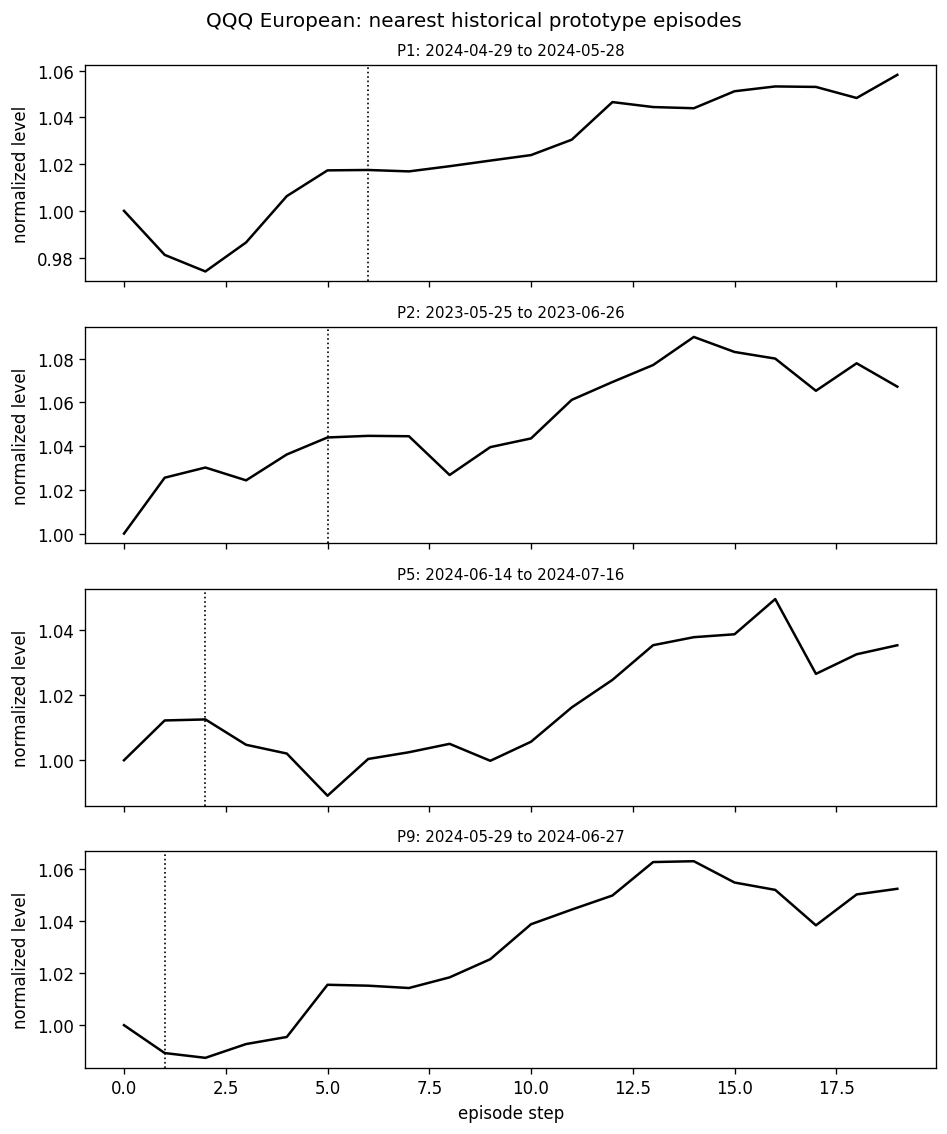

,liability_type,ticker,nominal_k,top1_mass_mean,top1_mass_std,top3_mass_mean,top3_mass_std,top5_mass_mean,top5_mass_std,top10_mass_mean,top10_mass_std,entropy_effective_k_mean,entropy_effective_k_std,inverse_concentration_effective_k_mean,inverse_concentration_effective_k_std
0,european_call,QQQ,10,0.244421,0.016827,0.581915,0.016446,0.831397,0.058706,1.0,1.359740e-16,7.309614,0.510472,6.322955,0.358446


,regime_type,regime,prototype,mean_weight
0,drawdown_regime,deep_dd,prototype_2,0.293173
1,drawdown_regime,mid_dd,prototype_2,0.259629
2,drawdown_regime,mild_dd,prototype_9,0.291415
3,return_regime,down,prototype_9,0.316480
4,return_regime,middle,prototype_9,0.211083
5,return_regime,up,prototype_2,0.374242
6,vol_regime,high_vol,prototype_2,0.249209
7,vol_regime,low_vol,prototype_5,0.232480
8,vol_regime,mid_vol,prototype_2,0.277073


,liability_type,ticker,prototype_index,nearest_rank,distance_scaled,test_path_index,episode_index,step_index,start_date,end_date,optionid,option_exdate,option_strike,delta_0,delta_1,price_0,price_1,time_left
9,european_call,QQQ,1,1,0.273000,541,3604,6,2024-04-29,2024-05-28,161521701,2024-06-07,439.0,0.686071,0.006843,1.017493,0.023720,0.055556
10,european_call,QQQ,1,2,0.290097,537,3600,4,2024-04-23,2024-05-21,161189248,2024-05-31,434.0,0.656427,0.009881,1.018068,0.022808,0.063492
11,european_call,QQQ,1,3,0.293866,545,3608,5,2024-05-03,2024-06-03,161521703,2024-06-07,441.0,0.708193,0.016587,1.015110,0.021229,0.059524
0,european_call,QQQ,2,1,0.428233,329,3392,5,2023-05-25,2023-06-26,148120859,2023-06-30,345.0,0.889324,-0.000864,1.043948,0.040666,0.059524
1,european_call,QQQ,2,2,0.445174,439,3502,4,2023-11-01,2023-11-30,157851306,2023-12-08,364.0,0.901608,0.002228,1.044095,0.039836,0.063492
2,european_call,QQQ,2,3,0.473079,230,3293,8,2022-12-30,2023-01-31,151639925,2023-02-03,272.5,0.819849,0.004408,1.047957,0.041892,0.047619
6,european_call,QQQ,5,1,1.126790,574,3637,2,2024-06-14,2024-07-16,159728329,2024-07-19,485.0,0.571110,0.002797,1.012563,0.019376,0.071429
7,european_call,QQQ,5,2,1.131525,545,3608,2,2024-05-03,2024-06-03,161521703,2024-06-07,441.0,0.549443,0.001295,1.011114,0.020862,0.071429
8,european_call,QQQ,5,3,1.133081,436,3499,2,2023-10-27,2023-11-27,157502607,2023-12-01,357.0,0.573570,0.003227,1.016101,0.018433,0.071429
3,european_call,QQQ,9,1,0.245978,562,3625,1,2024-05-29,2024-06-27,162115817,2024-07-05,468.0,0.348125,0.002824,0.989287,0.006014,0.075397


,stress_type,rank,episode_index,start_date,end_date,optionid,option_exdate,terminal_return,avg_ivol,max_drawdown,dominant_prototype,dominant_prototype_weight,mean_abs_spot_action,mean_abs_option_action,max_abs_spot_position,max_abs_option_position,proto_liability_offset,deep_hedging_liability_offset
0,lowest_return,1,3113,2022-04-13,2022-05-12,145035594,2022-05-20,-0.157384,0.296239,-0.157384,9,0.326522,0.250209,0.028410,0.678855,0.568197,-0.007302,-0.158407
1,lowest_return,2,3102,2022-03-29,2022-04-27,146203581,2022-05-06,-0.145613,0.241735,-0.145613,9,0.323355,0.192812,0.018336,0.950994,0.364903,-0.050504,-0.146363
2,lowest_return,3,3114,2022-04-14,2022-05-13,145035586,2022-05-20,-0.139704,0.315682,-0.159158,9,0.291812,0.205307,0.020795,0.838500,0.415899,-0.030783,-0.108060
3,lowest_return,4,3116,2022-04-19,2022-05-17,146373899,2022-05-27,-0.138104,0.297252,-0.159158,9,0.292834,0.258529,0.038808,0.636130,0.776165,0.002794,-0.115374
4,lowest_return,5,3106,2022-04-04,2022-05-03,146264222,2022-05-13,-0.137612,0.254600,-0.151774,9,0.300468,0.210254,0.027417,0.983226,0.548340,-0.032316,-0.135856
5,highest_implied_volatility,1,3238,2022-10-12,2022-11-09,150009455,2022-11-11,0.026194,0.383050,-0.083459,2,0.428773,0.114792,0.010680,0.981451,0.168625,0.007329,-0.000520
6,highest_implied_volatility,2,3239,2022-10-13,2022-11-10,150009462,2022-11-11,-0.020460,0.382508,-0.083459,2,0.305847,0.130941,0.007546,0.712047,0.135602,-0.050989,0.001334
7,highest_implied_volatility,3,3234,2022-10-06,2022-11-03,149886435,2022-11-04,-0.050329,0.362130,-0.067987,9,0.354016,0.176007,0.006909,0.677569,0.124526,-0.035695,-0.066978
8,highest_implied_volatility,4,3155,2022-06-14,2022-07-14,146975561,2022-07-15,0.035301,0.361701,-0.048640,2,0.429762,0.107965,0.011948,0.910525,0.235975,0.007645,-0.001327
9,highest_implied_volatility,5,3240,2022-10-14,2022-11-11,147530038,2022-11-18,0.084414,0.359150,-0.083459,2,0.450109,0.134394,0.017595,0.851619,0.293433,-0.026098,-0.002802


Interpretability deep dive: asian_call / QQQ


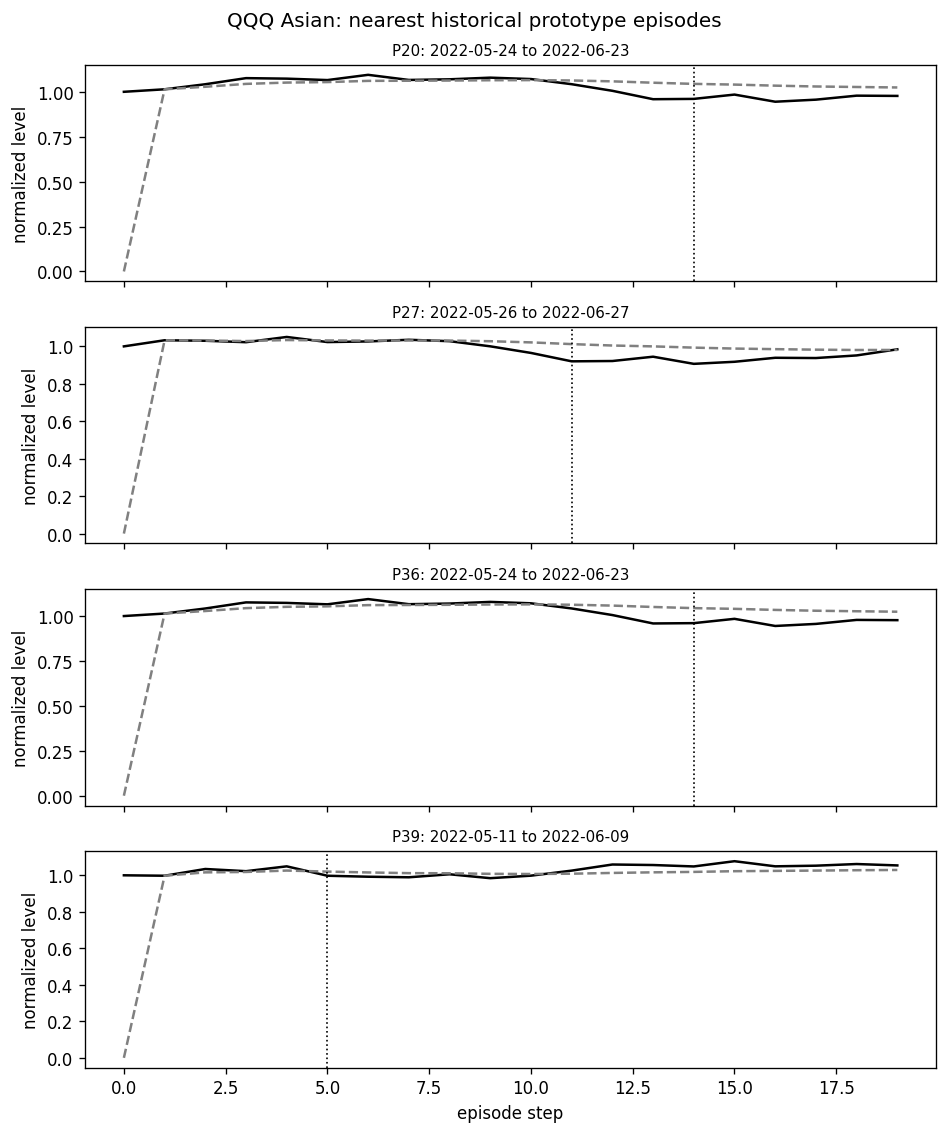

,liability_type,ticker,nominal_k,top1_mass_mean,top1_mass_std,top3_mass_mean,top3_mass_std,top5_mass_mean,top5_mass_std,top10_mass_mean,top10_mass_std,entropy_effective_k_mean,entropy_effective_k_std,inverse_concentration_effective_k_mean,inverse_concentration_effective_k_std
0,asian_call,QQQ,50,0.584835,0.439447,0.696014,0.427713,0.738105,0.391118,0.807349,0.311495,14.026784,20.676839,11.090495,16.7697


,regime_type,regime,prototype,mean_weight
0,drawdown_regime,deep_dd,prototype_39,0.922517
1,drawdown_regime,mid_dd,prototype_39,0.845524
2,drawdown_regime,mild_dd,prototype_39,0.714396
3,return_regime,down,prototype_39,0.744833
4,return_regime,middle,prototype_39,0.894103
5,return_regime,up,prototype_39,0.843712
6,vol_regime,high_vol,prototype_39,0.672463
7,vol_regime,low_vol,prototype_39,0.937702
8,vol_regime,mid_vol,prototype_39,0.872388


,liability_type,ticker,prototype_index,nearest_rank,distance_scaled,test_path_index,episode_index,step_index,start_date,end_date,optionid,option_exdate,option_strike,asian_moneyness,delta_0,delta_1,price_0,price_1,time_left
9,asian_call,QQQ,20,1,5.263795,78,3141,14,2022-05-24,2022-06-23,147033598,2022-06-24,287.0,1.044134,-0.017818,0.008831,0.960556,0.010235,0.023810
10,asian_call,QQQ,20,2,5.535591,199,3262,16,2022-11-15,2022-12-14,150771349,2022-12-23,289.0,0.988126,-0.038572,-0.038103,0.980856,0.015014,0.015873
11,asian_call,QQQ,20,3,5.550628,182,3245,13,2022-10-21,2022-11-18,150271046,2022-11-23,275.0,0.988432,0.019610,-0.048389,0.956067,0.009404,0.027778
3,asian_call,QQQ,27,1,6.270595,80,3143,11,2022-05-26,2022-06-27,147033662,2022-07-01,299.0,1.012060,-0.125123,-0.154015,0.920088,0.005980,0.035714
4,asian_call,QQQ,27,2,6.303463,58,3121,9,2022-04-26,2022-05-24,146422442,2022-05-27,318.0,0.996517,-0.056359,-0.147014,0.936968,0.008782,0.043651
5,asian_call,QQQ,27,3,6.339578,59,3122,8,2022-04-27,2022-05-25,146422441,2022-05-27,316.0,0.997427,-0.058736,-0.151226,0.938092,0.010402,0.047619
6,asian_call,QQQ,36,1,5.338222,78,3141,14,2022-05-24,2022-06-23,147033598,2022-06-24,287.0,1.044134,-0.017818,0.008831,0.960556,0.010235,0.023810
7,asian_call,QQQ,36,2,5.542568,199,3262,16,2022-11-15,2022-12-14,150771349,2022-12-23,289.0,0.988126,-0.038572,-0.038103,0.980856,0.015014,0.015873
8,asian_call,QQQ,36,3,5.648447,182,3245,13,2022-10-21,2022-11-18,150271046,2022-11-23,275.0,0.988432,0.019610,-0.048389,0.956067,0.009404,0.027778
0,asian_call,QQQ,39,1,5.843093,69,3132,5,2022-05-11,2022-06-09,146874937,2022-06-17,292.0,1.020313,0.013192,-0.137484,0.997602,0.040587,0.059524


,stress_type,rank,episode_index,start_date,end_date,optionid,option_exdate,terminal_return,avg_ivol,max_drawdown,dominant_prototype,dominant_prototype_weight,mean_abs_spot_action,mean_abs_option_action,max_abs_spot_position,max_abs_option_position,proto_liability_offset,deep_hedging_liability_offset
0,lowest_return,1,3113,2022-04-13,2022-05-12,145035594,2022-05-20,-0.157384,0.296239,-0.157384,39,0.497572,0.061367,0.050000,0.738932,1.000000,-0.052054,-0.025256
1,lowest_return,2,3102,2022-03-29,2022-04-27,146203581,2022-05-06,-0.145613,0.241735,-0.145613,39,0.466202,0.067801,0.050000,0.908392,1.000000,-0.077352,-0.023413
2,lowest_return,3,3114,2022-04-14,2022-05-13,145035586,2022-05-20,-0.139704,0.315682,-0.159158,39,0.618107,0.065558,0.050000,0.714324,1.000000,-0.003133,-0.031526
3,lowest_return,4,3116,2022-04-19,2022-05-17,146373899,2022-05-27,-0.138104,0.297252,-0.159158,39,0.354962,0.062194,0.050000,0.896402,1.000000,-0.015831,-0.033000
4,lowest_return,5,3106,2022-04-04,2022-05-03,146264222,2022-05-13,-0.137612,0.254600,-0.151774,27,0.450000,0.067155,0.050000,0.995356,1.000000,-0.067124,-0.026180
5,highest_implied_volatility,1,3238,2022-10-12,2022-11-09,150009455,2022-11-11,0.026194,0.383050,-0.083459,39,0.516483,0.094199,0.028447,0.399750,0.252276,-0.007691,-0.060062
6,highest_implied_volatility,2,3239,2022-10-13,2022-11-10,150009462,2022-11-11,-0.020460,0.382508,-0.083459,39,0.690899,0.066664,0.016378,0.285059,0.188187,-0.017283,-0.008163
7,highest_implied_volatility,3,3234,2022-10-06,2022-11-03,149886435,2022-11-04,-0.050329,0.362130,-0.067987,39,0.776554,0.054269,0.041450,0.316351,0.695272,0.018586,-0.035325
8,highest_implied_volatility,4,3155,2022-06-14,2022-07-14,146975561,2022-07-15,0.035301,0.361701,-0.048640,39,0.707201,0.066128,0.019912,0.268789,0.215234,-0.017911,-0.041276
9,highest_implied_volatility,5,3240,2022-10-14,2022-11-11,147530038,2022-11-18,0.084414,0.359150,-0.083459,39,0.550029,0.084377,0.030150,0.350366,0.313225,-0.001161,0.001108


In [9]:
def expanded_feature_cols(feature_names, world, input_dim):
    per_step = world.data.features.per_step
    n_inst = int(world.nInst)
    cols = []
    for name in sorted(feature_names):
        if name in per_step:
            arr = np.asarray(per_step[name])
            width = 1 if arr.ndim == 2 else int(arr.shape[-1])
        elif name in ('delta', 'action'):
            width = n_inst
        else:
            width = 1
        cols.extend([name] if width == 1 else [f'{name}_{j}' for j in range(width)])
    return cols if len(cols) == int(input_dim) else [f'feature_{i}' for i in range(int(input_dim))]


def deep_dive(liability_type, ticker=DEEP_DIVE_TICKER):
    out_dir = ticker_output_dir(liability_type, ticker)
    best = pd.read_csv(out_dir / 'paper_best_models.csv')
    best_row = select_row(best, DEEP_DIVE_SELECTION)
    target_model = str(best_row['model'])
    artifacts = list_saved_artifacts(out_dir)
    proto_rows = artifacts[(artifacts['model_name'].eq(target_model)) & artifacts['risk_measure'].eq('cvar')]
    assert set(proto_rows['seed']) == set(SEEDS), 'Interpretability requires all selected-model seed artifacts'

    seed_concentration_rows = []
    for _, seed_artifact in proto_rows.sort_values('seed').iterrows():
        seed_bundle, seed_result, _ = evaluate_saved_artifact(seed_artifact['artifact_dir'], split='test')
        _, seed_usage = prototype_usage_table(seed_bundle, seed_result, top_n=10)
        seed_usage = seed_usage.sort_values('usage_mean', ascending=False).reset_index(drop=True)
        probabilities = seed_usage['usage_mean'].to_numpy(float)
        probabilities = probabilities / probabilities.sum()
        cumulative = probabilities.cumsum()
        seed_concentration_rows.append({
            'liability_type': liability_type,
            'ticker': ticker,
            'seed': int(seed_artifact['seed']),
            'nominal_k': len(probabilities),
            'top1_mass': cumulative[0],
            'top3_mass': cumulative[min(2, len(probabilities) - 1)],
            'top5_mass': cumulative[min(4, len(probabilities) - 1)],
            'top10_mass': cumulative[min(9, len(probabilities) - 1)],
            'entropy_effective_k': float(np.exp(-(probabilities[probabilities > 0] * np.log(probabilities[probabilities > 0])).sum())),
            'inverse_concentration_effective_k': float(1.0 / np.square(probabilities).sum()),
        })
    seed_concentration = pd.DataFrame(seed_concentration_rows)
    concentration_metrics = [
        'top1_mass', 'top3_mass', 'top5_mass', 'top10_mass',
        'entropy_effective_k', 'inverse_concentration_effective_k',
    ]
    effective_summary = seed_concentration.groupby(
        ['liability_type', 'ticker', 'nominal_k'], as_index=False
    ).agg(**{
        f'{metric}_{stat}': (metric, stat)
        for metric in concentration_metrics
        for stat in ('mean', 'std')
    })

    seed_rows = proto_rows[proto_rows['seed'].eq(DEEP_DIVE_SEED)]
    artifact_dir = Path((seed_rows if not seed_rows.empty else proto_rows).iloc[0]['artifact_dir'])

    bundle, proto_result, _ = evaluate_saved_artifact(artifact_dir, split='test')
    if liability_type == 'asian_call':
        assert bundle['metadata']['payoff_state_version'] == ASIAN_PAYOFF_STATE_VERSION
        assert ASIAN_PAYOFF_FEATURE in bundle['metadata']['model_features']

    baselines = evaluate_saved_baselines(artifact_dir, split='test')
    vanilla_rows = artifacts[(artifacts['model_name'].eq('vanilla')) & artifacts['risk_measure'].eq('cvar')]
    vanilla_seed = vanilla_rows[vanilla_rows['seed'].eq(DEEP_DIVE_SEED)]
    vanilla_dir = Path((vanilla_seed if not vanilla_seed.empty else vanilla_rows).iloc[0]['artifact_dir'])
    _, vanilla_result, _ = evaluate_saved_artifact(vanilla_dir, split='test')

    result_dict = {
        'proto': proto_result,
        'deep_hedging': vanilla_result,
        'spot_delta_band': baselines['spot_delta_band']['result'],
        'unhedged': baselines['unhedged']['result'],
    }
    regime_frame = build_regime_frame(bundle['eval_world'], result_dict)
    regime_summary = pd.concat([
        summarize_by_regime(regime_frame, 'return_regime'),
        summarize_by_regime(regime_frame, 'vol_regime'),
        summarize_by_regime(regime_frame, 'drawdown_regime'),
    ], ignore_index=True)

    top_proto, all_proto = prototype_usage_table(bundle, proto_result, top_n=10)
    usage_by_regime = prototype_usage_by_regime(proto_result, regime_frame)
    dominant_regime = usage_by_regime.loc[
        usage_by_regime.groupby(['regime_type', 'regime'], observed=True)['mean_weight'].idxmax()
    ].sort_values(['regime_type', 'regime']).reset_index(drop=True)

    concentration = all_proto.sort_values('usage_mean', ascending=False).reset_index(drop=True).copy()
    concentration['k'] = np.arange(1, len(concentration) + 1)
    concentration['cum_usage_mean'] = concentration['usage_mean'].cumsum()
    p = concentration['usage_mean'].to_numpy(float)
    p = p / p.sum()
    effective = pd.DataFrame([{
        'liability_type': liability_type,
        'ticker': ticker,
        'nominal_k': len(p),
        'top1_mass': concentration.loc[0, 'cum_usage_mean'],
        'top3_mass': concentration.loc[min(2, len(p)-1), 'cum_usage_mean'],
        'top5_mass': concentration.loc[min(4, len(p)-1), 'cum_usage_mean'],
        'top10_mass': concentration.loc[min(9, len(p)-1), 'cum_usage_mean'],
        'entropy_effective_k': float(np.exp(-(p[p > 0] * np.log(p[p > 0])).sum())),
        'inverse_concentration_effective_k': float(1.0 / np.square(p).sum()),
    }])

    payload = load_prototype_payload(bundle['metadata']['prototype_path'])
    prototypes_scaled = np.asarray(payload['prototypes'], dtype=np.float32)
    scaler = payload['scaler']
    feature_names = payload.get('feature_names', model_features_for_liability(liability_type))
    x_raw, feature_names_sorted = extract_agent_feature_matrix(
        world=bundle['eval_world'], result=proto_result, feature_names=feature_names,
    )
    x_scaled = scaler.transform(x_raw)
    feature_cols = expanded_feature_cols(feature_names_sorted, bundle['eval_world'], x_raw.shape[1])
    n_steps = int(bundle['eval_world'].data.market.hedges.shape[1])
    test_episode_indices = np.asarray(bundle['metadata']['split_indices']['test'], dtype=int)
    manifest_row = manifest[manifest['ticker'].eq(ticker)].iloc[0]
    episode_meta = pd.read_csv(manifest_row['episode_metadata_path']).set_index('episode_index')

    nearest_rows = []
    for proto_idx in top_proto['prototype_index'].head(4).astype(int):
        distances = np.linalg.norm(x_scaled - prototypes_scaled[proto_idx], axis=1)
        for rank, flat_idx in enumerate(np.argsort(distances)[:3], start=1):
            path_idx = int(flat_idx // n_steps)
            step_idx = int(flat_idx % n_steps)
            episode_index = int(test_episode_indices[path_idx])
            meta = episode_meta.loc[episode_index]
            item = {
                'liability_type': liability_type,
                'ticker': ticker,
                'prototype_index': int(proto_idx),
                'nearest_rank': rank,
                'distance_scaled': float(distances[flat_idx]),
                'test_path_index': path_idx,
                'episode_index': episode_index,
                'step_index': step_idx,
                'start_date': meta['start_date'],
                'end_date': meta['end_date'],
                'optionid': meta['optionid'],
                'option_exdate': meta['option_exdate'],
                'option_strike': meta['option_strike'],
            }
            item.update({col: float(x_raw[flat_idx, j]) for j, col in enumerate(feature_cols)})
            nearest_rows.append(item)
    nearest = pd.DataFrame(nearest_rows).sort_values(['prototype_index', 'nearest_rank'])

    weights_array = proto_result['prototype_weights']
    weights_array = weights_array.detach().cpu().numpy() if torch.is_tensor(weights_array) else np.asarray(weights_array)
    actions_array = proto_result['actions']
    actions_array = actions_array.detach().cpu().numpy() if torch.is_tensor(actions_array) else np.asarray(actions_array)
    deltas_array = proto_result['deltas']
    deltas_array = deltas_array.detach().cpu().numpy() if torch.is_tensor(deltas_array) else np.asarray(deltas_array)
    episode_weights = weights_array.mean(axis=1)
    stress_base = regime_frame.copy()
    stress_meta = episode_meta.loc[test_episode_indices].reset_index()
    for col in ['episode_index', 'start_date', 'end_date', 'optionid', 'option_exdate', 'option_strike']:
        stress_base[col] = stress_meta[col].to_numpy()
    stress_base['dominant_prototype'] = episode_weights.argmax(axis=1)
    stress_base['dominant_prototype_weight'] = episode_weights.max(axis=1)
    stress_base['mean_abs_spot_action'] = np.abs(actions_array[:, :, 0]).mean(axis=1)
    stress_base['mean_abs_option_action'] = np.abs(actions_array[:, :, 1]).mean(axis=1)
    stress_base['max_abs_spot_position'] = np.abs(deltas_array[:, :, 0]).max(axis=1)
    stress_base['max_abs_option_position'] = np.abs(deltas_array[:, :, 1]).max(axis=1)
    stress_rows = []
    stress_specs = [
        ('lowest_return', 'terminal_return', True),
        ('highest_implied_volatility', 'avg_ivol', False),
        ('deepest_drawdown', 'max_drawdown', True),
    ]
    stress_columns = [
        'episode_index', 'start_date', 'end_date', 'optionid', 'option_exdate',
        'terminal_return', 'avg_ivol', 'max_drawdown', 'dominant_prototype',
        'dominant_prototype_weight', 'mean_abs_spot_action',
        'mean_abs_option_action', 'max_abs_spot_position', 'max_abs_option_position',
        'proto_liability_offset', 'deep_hedging_liability_offset',
    ]
    for stress_type, metric, ascending in stress_specs:
        ranked = stress_base.sort_values(metric, ascending=ascending).head(5)
        for rank, (_, stress_row) in enumerate(ranked.iterrows(), start=1):
            item = {'stress_type': stress_type, 'rank': rank}
            item.update({col: stress_row[col] for col in stress_columns})
            stress_rows.append(item)
    stress_episodes = pd.DataFrame(stress_rows)

    table_dir = ASSET_ROOT / liability_type / 'interpretability' / 'tables'
    save_table(top_proto, table_dir / f'{ticker.lower()}_prototype_top10')
    save_table(concentration, table_dir / f'{ticker.lower()}_prototype_concentration')
    save_table(effective, table_dir / f'{ticker.lower()}_prototype_effective_size_representative_seed')
    save_table(seed_concentration, table_dir / f'{ticker.lower()}_prototype_effective_size_by_seed')
    save_table(effective_summary, table_dir / f'{ticker.lower()}_prototype_effective_size')
    save_table(usage_by_regime, table_dir / f'{ticker.lower()}_prototype_usage_by_regime')
    save_table(dominant_regime, table_dir / f'{ticker.lower()}_dominant_prototype_by_regime')
    save_table(regime_summary, table_dir / f'{ticker.lower()}_regime_performance')
    save_table(nearest, table_dir / f'{ticker.lower()}_nearest_historical_states')
    save_table(stress_episodes, table_dir / f'{ticker.lower()}_stress_historical_episodes')

    fig_dir = ASSET_ROOT / liability_type / 'interpretability' / 'figures'
    fig_dir.mkdir(parents=True, exist_ok=True)
    first_neighbors = nearest[nearest['nearest_rank'].eq(1)].head(4)
    fig, axes = plt.subplots(len(first_neighbors), 1, figsize=(8, 2.4 * len(first_neighbors)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, (_, item) in zip(axes, first_neighbors.iterrows()):
        path_idx = int(item['test_path_index'])
        step_idx = int(item['step_index'])
        spot = np.asarray(bundle['eval_world'].data.features.per_step['spot'])[path_idx]
        ax.plot(np.arange(len(spot)), spot, color='black', linewidth=1.5)
        if liability_type == 'asian_call':
            running = np.asarray(bundle['eval_world'].data.features.per_step['asian_running_average'])[path_idx]
            ax.plot(np.arange(len(running)), running, color='gray', linestyle='--', label='running average')
        ax.axvline(step_idx, color='black', linestyle=':', linewidth=1)
        ax.set_title(f"P{int(item['prototype_index'])}: {item['start_date']} to {item['end_date']}", fontsize=9)
        ax.set_ylabel('normalized level')
    axes[-1].set_xlabel('episode step')
    fig.suptitle(f'{ticker} {LIABILITY_CONFIGS[liability_type]["label"]}: nearest historical prototype episodes')
    fig.tight_layout()
    fig.savefig(fig_dir / f'{ticker.lower()}_nearest_historical_episodes.png', dpi=180, bbox_inches='tight')
    plt.show()
    return {
        'effective': effective_summary,
        'effective_by_seed': seed_concentration,
        'dominant_regime': dominant_regime,
        'nearest': nearest,
        'stress_episodes': stress_episodes,
        'top_proto': top_proto,
    }


interpretability_results = {}
if RUN_ANALYSIS:
    for liability_type in LIABILITY_CONFIGS:
        print(f'Interpretability deep dive: {liability_type} / {DEEP_DIVE_TICKER}')
        interpretability_results[liability_type] = deep_dive(liability_type)
        display(interpretability_results[liability_type]['effective'])
        display(interpretability_results[liability_type]['dominant_regime'])
        display(interpretability_results[liability_type]['nearest'].head(12))
        display(interpretability_results[liability_type]['stress_episodes'])
else:
    print('RUN_ANALYSIS=False: interpretability analysis skipped')


## 9. Final Asset and Protocol Audit

The final cell records every exported asset and the locked configuration. A successful run ends with both completion and asset manifests written to disk.


In [10]:
protocol = {
    'run_version': RUN_VERSION,
    'created_utc': datetime.now(timezone.utc).isoformat(),
    'tickers': manifest['ticker'].tolist(),
    'liabilities': list(LIABILITY_CONFIGS),
    'seeds': list(SEEDS),
    'epochs': EPOCHS,
    'learning_rate': LEARNING_RATE,
    'batch_size': BATCH_SIZE,
    'epoch_refresh': EPOCH_REFRESH,
    'spot_delta_band_grid': list(SPOT_DELTA_BAND_GRID),
    'prototype_counts': list(PROTOTYPE_COUNTS),
    'prototype_sources': list(PROTOTYPE_SOURCES),
    'weighted_similarity_options': list(WEIGHTED_SIMILARITY_OPTIONS),
    'outcome_definition': OUTCOME_DEFINITION_VERSION,
    'premium_included': PREMIUM_INCLUDED,
    'hedge_accounting_version': HEDGE_ACCOUNTING_VERSION,
    'episode_timing_version': EPISODE_TIMING_VERSION,
    'n_decisions': 20,
    'n_observations': 21,
    'inference_version': INFERENCE_VERSION,
    'temporal_split_version': TEMPORAL_SPLIT_VERSION,
    'option_path_version': OPTION_PATH_VERSION,
    'model_selection_version': MODEL_SELECTION_VERSION,
    'asian_payoff_state_version': ASIAN_PAYOFF_STATE_VERSION,
    'bootstrap_repetitions': BOOTSTRAP_REPETITIONS,
    'bootstrap_confidence': BOOTSTRAP_CONFIDENCE,
    'bootstrap_block_length': BOOTSTRAP_BLOCK_LENGTH,
    'training_selection': TRAIN_SELECTION,
    'training_regularization': TRAIN_REGULARIZATION,
    'max_validation_bound_occupancy': MAX_VALIDATION_BOUND_OCCUPANCY,
    'trade_bounds': TRADE_BOUNDS,
    'position_bounds': POSITION_BOUNDS,
}
(RUN_ROOT / 'locked_protocol.json').write_text(json.dumps(protocol, indent=2))
(ASSET_ROOT / 'locked_protocol.json').write_text(json.dumps(protocol, indent=2))

asset_rows = []
for path in sorted(ASSET_ROOT.rglob('*')):
    if path.is_file():
        asset_rows.append({
            'relative_path': str(path.relative_to(ASSET_ROOT)),
            'bytes': path.stat().st_size,
            'suffix': path.suffix,
        })
asset_manifest = pd.DataFrame(asset_rows)
asset_manifest.to_csv(ASSET_ROOT / 'asset_manifest.csv', index=False)

print('run outputs:', RUN_ROOT)
print('paper assets:', ASSET_ROOT)
print('asset count:', len(asset_manifest))
if RUN_ANALYSIS:
    assert completion_df['complete'].all()
    required_assets = {
        'combined/tables/dataset_episode_summary.csv',
        'combined/tables/european_asian_panel_averages.csv',
        'combined/tables/cross_liability_proto_vs_deep_hedging.csv',
        'combined/tables/cross_liability_block_bootstrap.csv',
    }
    for liability_type in LIABILITY_CONFIGS:
        required_assets.update({
            f'{liability_type}/tables/panel_average_table.csv',
            f'{liability_type}/tables/panel_ticker_table.csv',
            f'{liability_type}/tables/validation_selected_configurations.csv',
            f'{liability_type}/tables/per_ticker_paired_block_bootstrap.csv',
            f'{liability_type}/tables/equal_ticker_paired_block_bootstrap.csv',
            f'{liability_type}/tables/proto_vs_deep_hedging_summary.csv',
            f'{liability_type}/tables/panel_model_metrics.csv',
            f'{liability_type}/interpretability/tables/qqq_prototype_top10.csv',
            f'{liability_type}/interpretability/tables/qqq_prototype_concentration.csv',
            f'{liability_type}/interpretability/tables/qqq_prototype_effective_size.csv',
            f'{liability_type}/interpretability/tables/qqq_prototype_effective_size_by_seed.csv',
            f'{liability_type}/interpretability/tables/qqq_stress_historical_episodes.csv',
            f'{liability_type}/interpretability/tables/qqq_prototype_usage_by_regime.csv',
            f'{liability_type}/interpretability/tables/qqq_dominant_prototype_by_regime.csv',
            f'{liability_type}/interpretability/tables/qqq_regime_performance.csv',
            f'{liability_type}/interpretability/tables/qqq_nearest_historical_states.csv',
            f'{liability_type}/interpretability/figures/qqq_nearest_historical_episodes.png',
        })
    required_assets.update({
        path[:-4] + '.tex' for path in tuple(required_assets) if path.endswith('.csv')
    })
    actual_assets = set(asset_manifest['relative_path'])
    missing_assets = sorted(required_assets - actual_assets)
    assert not missing_assets, f'Missing required paper assets: {missing_assets}'
    assert (asset_manifest['bytes'] > 0).all(), 'At least one paper asset is empty'
    print('DEFINITIVE EMPIRICAL RERUN COMPLETE')
else:
    print('DRY VALIDATION COMPLETE: training and analysis were intentionally disabled')
display(asset_manifest.tail(30))


run outputs: /Users/yaniszaim/deephedging/.deephedging_real_runs/submission_rerun_scientific_v4
paper assets: /Users/yaniszaim/deephedging/paper/submission_rerun_scientific_v4
asset count: 80
DEFINITIVE EMPIRICAL RERUN COMPLETE


,relative_path,bytes,suffix
50,european_call/interpretability/tables/qqq_prot...,1444,.tex
51,european_call/interpretability/tables/qqq_prot...,514,.csv
52,european_call/interpretability/tables/qqq_prot...,577,.tex
53,european_call/interpretability/tables/qqq_prot...,520,.csv
54,european_call/interpretability/tables/qqq_prot...,542,.tex
55,european_call/interpretability/tables/qqq_prot...,262,.csv
56,european_call/interpretability/tables/qqq_prot...,323,.tex
57,european_call/interpretability/tables/qqq_prot...,1762,.csv
58,european_call/interpretability/tables/qqq_prot...,1268,.tex
59,european_call/interpretability/tables/qqq_prot...,4802,.csv
